# 06. The official test set, opened once

## The rule, written before it is applied

The official test set has not been consulted at any point in this project. Only
its size and its positive rate have been used, two figures published with the
dataset.

It is opened once, in this notebook, on the model frozen in notebook 05 and
recorded by the Git tag `model-frozen`.

The discipline is not only about technical leakage. If the result disappoints,
the temptation to try another model, then another threshold, is strong and easy
to rationalise. After three attempts the test set is no longer an independent
judge, and nothing signals that it has stopped being one.

## What is measured

Total cost, detection rate, alert reliability, area under both curves, the
confusion counts, and the ratio to the cheaper constant rule.

## What stays allowed after the opening

Descriptive analysis of the errors, with no change to the model.

The threshold that would have been optimal on the test set, reported only as a
measure of how stable the operating point is, never as a result.

Variable importance on the frozen model.

## What is forbidden

Changing model after seeing the result. Reporting a cost obtained with a
threshold tuned on the test set. Retraining anything on these rows.

## A result below the reserved rows is expected

The model and its threshold were chosen on earlier measurements, of which they
captured some of the particular noise. A gap of a few percent is healthy. A large
gap on cost with a stable area under the precision-recall curve would point at
the threshold rather than at the model.

In [1]:
import sys
sys.path.append("..")

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import (BAYES_THRESHOLD, COST_FN, COST_FP, FIGURES_DIR,
                        MODELS_DIR, ROOT)
from src.cost import best_threshold, constant_rule_costs, total_cost
from src.data import load_sealed_test
from src.preprocessing import load as load_artifact
from src.seeding import set_seed

set_seed()

with open(MODELS_DIR / "final_model.json", encoding="utf-8") as handle:
    manifest = json.load(handle)

print("Model frozen in notebook 05\n")
for key, value in manifest.items():
    if key != "columns":
        print(f"  {key:<24} {value}")
print(f"  {'columns':<24} {len(manifest['columns'])}")

2026-09-03 17:26:35.204801: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-03 17:26:35.253296: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model frozen in notebook 05

  model                    gradient boosting
  threshold                0.0023719617165625095
  deciding_criterion       stability across partitions
  fitted_on                48 000 fitting rows
  repeated_cv_cost         6674.666666666667
  repeated_cv_std          1203.018426015717
  reserved_cost            6410.0
  reserved_recall          0.97
  reserved_missed          6
  reserved_false_alarms    341
  reserved_reference       100000
  brier                    0.005174
  mean_probability         0.016458
  actual_rate              0.016667
  columns                  180


## 1. Replaying the preparation chain

The test file is raw. It carries the same missing values and the same
heterogeneous scales as the training file, and it must go through exactly the
same preparation.

Exactly has a precise meaning here. The imputation medians and the scaling
parameters were estimated on the 48 000 fitting rows. Those are the values
applied, not values recomputed on the test set. Recomputing would let the test
set define its own preparation, which is the definition of a leak.

The serialised objects written by `scripts/build_dataset.py` exist for this
replay. This is what they are for, and this cell is the check that they work.

In [2]:
X_test_raw, y_test = load_sealed_test()

print(f"test file : {X_test_raw.shape[0]:,} rows, {X_test_raw.shape[1]} columns")
print(f"failures  : {int(y_test.sum())} ({y_test.mean():.4%})")
print(f"missing   : {X_test_raw.isna().to_numpy().mean():.2%} of cells")

encoder = load_artifact("missingness_encoder.joblib")
preprocessor = load_artifact("preprocessor.joblib")

X_test = preprocessor.transform(encoder.transform(X_test_raw))

print(f"\nafter preparation : {X_test.shape}")
print(f"empty cells       : {int(X_test.isna().sum().sum())}")

assert list(X_test.columns) == manifest["columns"], "column mismatch"
print("\ncolumns match the frozen model exactly, in the same order")

test file : 16,000 rows, 170 columns
failures  : 375 (2.3438%)
missing   : 8.41% of cells

after preparation : (16000, 180)
empty cells       : 0

columns match the frozen model exactly, in the same order


In [3]:
rules = constant_rule_costs(y_test)
reference = min(rules["never_flag"], rules["always_flag"])

print(f"on the {len(y_test):,} test rows")
print(f"  never flag  : {rules['never_flag']:>8,}")
print(f"  always flag : {rules['always_flag']:>8,}")
print(f"  reference   : {reference:>8,}")

print(f"\nThe test positive rate is {y_test.mean():.2%}, above the break-even")
print(f"rate of {BAYES_THRESHOLD:.2%}. The cheaper constant rule is therefore")
print("not the same one as on the fitting data, which sits at 1.67%.")

published = pd.DataFrame([
    {"source": "IDA 2016 winner", "cost": 9920, "FP": 542, "FN": 9},
    {"source": "IDA 2016 runner-up", "cost": 10900, "FP": 490, "FN": 12},
    {"source": "IDA 2016 third", "cost": 11480, "FP": 398, "FN": 15},
    {"source": "constant rule", "cost": 156250, "FP": 15625, "FN": 0},
])
print("\npublished references on this same test set")
print(published.to_string(index=False))

on the 16,000 test rows
  never flag  :  187,500
  always flag :  156,250
  reference   :  156,250

The test positive rate is 2.34%, above the break-even
rate of 1.96%. The cheaper constant rule is therefore
not the same one as on the fitting data, which sits at 1.67%.

published references on this same test set
            source   cost    FP  FN
   IDA 2016 winner   9920   542   9
IDA 2016 runner-up  10900   490  12
    IDA 2016 third  11480   398  15
     constant rule 156250 15625   0


## 2. Converting earlier measurements to this scale

Cost is extensive in the number of rows, so a cost read on a cross-validation
fold is not directly comparable to one read on the test set. Between the fitting
data and the reserved rows a single factor was exact, both carrying the same
positive rate. It is not exact here: the test set holds 2.34% positives against
1.67%.

The two terms therefore convert separately. Missed failures scale with the number
of failures, false alarms with the number of healthy trucks. Applying a single
factor would understate the expected cost, because the failure term dominates and
grows faster than the other.

In [4]:
def to_test_scale(cost, missed, rows, positives):
    """Convert a cost measured on one set to the test scale, term by term.

    Missed failures scale with the number of failures, false alarms with the
    number of healthy trucks. A single factor would be wrong here because the
    two sets do not share a positive rate.
    """
    test_positives = int(y_test.sum())
    test_negatives = len(y_test) - test_positives

    missed_cost = missed * COST_FN
    alarm_cost = cost - missed_cost
    return (missed_cost * test_positives / positives
            + alarm_cost * test_negatives / (rows - positives))


repeated = pd.read_csv(ROOT / "reports" / "runs" / "finalists_r6.csv")
arbitration = pd.read_csv(ROOT / "reports" / "arbitration.csv", index_col=0)
selected = manifest["model"]

cv = repeated[repeated["model"] == selected]
expected_from_cv = to_test_scale(cv["cost"].mean(), cv["FN"].mean(), 9600, 160)
expected_from_reserved = to_test_scale(arbitration.loc[selected, "cost"],
                                       arbitration.loc[selected, "FN"],
                                       len(y_test) * 0 + 12000, 200)

print(f"expected on the test scale, from repeated cross-validation : "
      f"{expected_from_cv:,.0f}")
print(f"expected on the test scale, from the reserved rows         : "
      f"{expected_from_reserved:,.0f}")


expected on the test scale, from repeated cross-validation : 13,814
expected on the test scale, from the reserved rows         : 10,140


In [5]:
import joblib

stem = selected.replace(" ", "_")
path = MODELS_DIR / f"{stem}.joblib"

if path.exists():
    model = joblib.load(path)
else:
    from tensorflow import keras
    model = keras.models.load_model(MODELS_DIR / f"{stem}.keras", compile=False)

threshold = manifest["threshold"]

start = time.time()
if hasattr(model, "predict_proba"):
    probability = model.predict_proba(X_test)[:, 1]
else:
    probability = model.predict(np.asarray(X_test, dtype="float32"),
                               batch_size=1024, verbose=0).ravel()
elapsed = time.time() - start

predicted = (probability >= threshold).astype(int)

print(f"model     : {selected}")
print(f"threshold : {threshold:.6f}, chosen on the fitting rows")
print(f"inference : {len(y_test):,} rows in {elapsed:.2f} s")

np.save(ROOT / "reports" / "test_probability.npy", probability)
print("\nprobabilities saved, the analyses below reuse them")

model     : gradient boosting
threshold : 0.002372, chosen on the fitting rows
inference : 16,000 rows in 0.16 s

probabilities saved, the analyses below reuse them


In [6]:
from sklearn.metrics import (average_precision_score, precision_score,
                             recall_score, roc_auc_score)

y = y_test.to_numpy()
tp = int(((predicted == 1) & (y == 1)).sum())
fp = int(((predicted == 1) & (y == 0)).sum())
fn = int(((predicted == 0) & (y == 1)).sum())
tn = int(((predicted == 0) & (y == 0)).sum())
cost = total_cost(y, predicted)

result = {
    "model": selected,
    "threshold": threshold,
    "cost": cost,
    "recall": recall_score(y, predicted, zero_division=0),
    "precision": precision_score(y, predicted, zero_division=0),
    "auc": roc_auc_score(y, probability),
    "auc_pr": average_precision_score(y, probability),
    "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    "reference": int(reference),
    "saving_pct": round(100 * (1 - cost / reference), 2),
}

print("=" * 62)
print("  RESULT ON THE OFFICIAL TEST SET")
print("=" * 62)
print(f"  total cost              : {cost:>10,}")
print(f"  constant-rule reference : {reference:>10,}")
print(f"  saving                  : {result['saving_pct']:>9.1f} %")
print("=" * 62)
print(f"  failures detected       : {tp:>10} of {int(y.sum())}")
print(f"  failures missed         : {fn:>10}")
print(f"  false alarms            : {fp:>10}")
print(f"  correctly cleared       : {tn:>10,}")
print("-" * 62)
print(f"  detection rate          : {result['recall']:>9.1%}")
print(f"  alert reliability       : {result['precision']:>9.1%}")
print(f"  area under ROC          : {result['auc']:>9.4f}")
print(f"  area under PR           : {result['auc_pr']:>9.4f}")
print("=" * 62)

  RESULT ON THE OFFICIAL TEST SET
  total cost              :     11,370
  constant-rule reference :    156,250
  saving                  :      92.7 %
  failures detected       :        360 of 375
  failures missed         :         15
  false alarms            :        387
  correctly cleared       :     15,238
--------------------------------------------------------------
  detection rate          :     96.0%
  alert reliability       :     48.2%
  area under ROC          :    0.9943
  area under PR           :    0.9267


In [7]:
# Diagnostic only, explicitly not reported as a result
post_hoc_threshold, post_hoc_cost = best_threshold(y, probability)

print("DIAGNOSTIC, NOT A REPORTED RESULT\n")
print(f"threshold applied, chosen before the opening : {threshold:.6f}")
print(f"threshold that would have been optimal here  : {post_hoc_threshold:.6f}")
print(f"cost obtained                                : {cost:,}")
print(f"cost that threshold would have given         : {post_hoc_cost:,}")
print(f"difference                                   : {cost - post_hoc_cost:,}")

print("\nThis gap measures how well the operating point transports. A small gap")
print("means the threshold tuned on the fitting rows carries over. The reported")
print("cost stays the one obtained with the threshold chosen before the")
print("opening; reporting the other would be tuning on the test set.")

result["diagnostic_optimal_threshold"] = float(post_hoc_threshold)
result["diagnostic_cost_at_that_threshold"] = int(post_hoc_cost)

DIAGNOSTIC, NOT A REPORTED RESULT

threshold applied, chosen before the opening : 0.002372
threshold that would have been optimal here  : 0.001082
cost obtained                                : 11,370
cost that threshold would have given         : 10,060
difference                                   : 1,310

This gap measures how well the operating point transports. A small gap
means the threshold tuned on the fitting rows carries over. The reported
cost stays the one obtained with the threshold chosen before the
opening; reporting the other would be tuning on the test set.


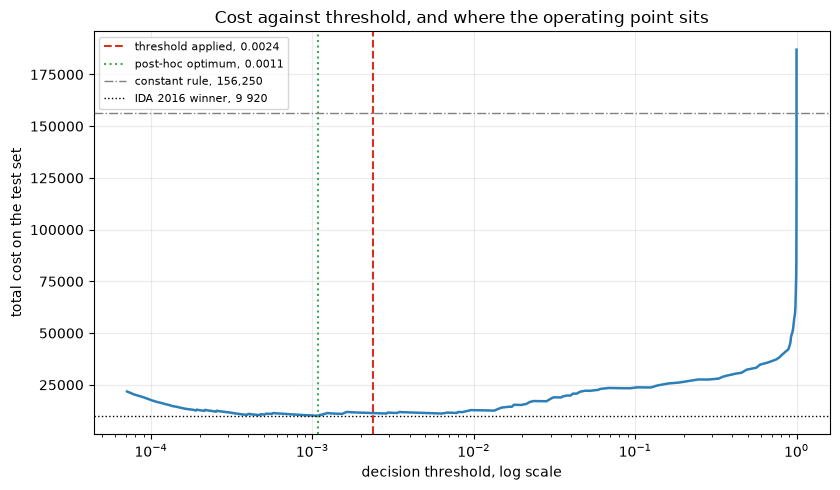

In [8]:
# Figure: cost as a function of the threshold, with both operating points
grid = np.unique(np.quantile(probability, np.linspace(0.85, 1.0, 500)))
costs = [total_cost(y, (probability >= t).astype(int)) for t in grid]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(grid, costs, color="#2c7fb8", lw=1.8)
ax.axvline(threshold, color="#d7301f", ls="--", lw=1.5,
           label=f"threshold applied, {threshold:.4f}")
ax.axvline(post_hoc_threshold, color="#41ab5d", ls=":", lw=1.5,
           label=f"post-hoc optimum, {post_hoc_threshold:.4f}")
ax.axhline(reference, color="grey", ls="-.", lw=1,
           label=f"constant rule, {reference:,}")
ax.axhline(9920, color="black", ls=":", lw=1, label="IDA 2016 winner, 9 920")

ax.set_xscale("log")
ax.set_xlabel("decision threshold, log scale")
ax.set_ylabel("total cost on the test set")
ax.set_title("Cost against threshold, and where the operating point sits")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_cost_vs_threshold.png", dpi=150)
plt.show()

In [9]:
ranking = published.copy()
ranking.loc[len(ranking)] = {"source": "this project", "cost": cost,
                             "FP": fp, "FN": fn}
ranking = ranking.sort_values("cost").reset_index(drop=True)
print(ranking.to_string(index=False))

            source   cost    FP  FN
   IDA 2016 winner   9920   542   9
IDA 2016 runner-up  10900   490  12
      this project  11370   387  15
    IDA 2016 third  11480   398  15
     constant rule 156250 15625   0


## How this table should be read

The 2016 winner accepts 542 false alarms to miss only 9 failures, while the third
placed accepts 398 but misses 15. The winning strategy is therefore to consent to
more useless inspections in order to miss fewer failures, which follows directly
from the 50 to 1 cost ratio. A model that looks conservative on alerts is, on
this metric, an expensive one.

Two reservations belong with any comparison to these numbers.

The 2016 results were produced blind, in competition. The test labels have been
public since, so results published afterwards are not comparable in the same way,
and a steady improvement on a fixed public test set is compatible with collective
overfitting whose size cannot be measured from outside.

This project's parameter search is deliberately coarse and of comparable size
across the five models. The figure above is that of a coarsely tuned model, not
of a model at its best.

In [10]:
progression = pd.DataFrame([
    {"measurement": "repeated cross-validation", "rows": 9600, "failures": 160,
     "cost": cv["cost"].mean(), "expected_on_test": expected_from_cv},
    {"measurement": "reserved rows", "rows": 12000, "failures": 200,
     "cost": arbitration.loc[selected, "cost"],
     "expected_on_test": expected_from_reserved},
    {"measurement": "official test set", "rows": len(y), "failures": int(y.sum()),
     "cost": cost, "expected_on_test": cost},
])
progression["cost_per_failure"] = (progression["cost"]
                                   / progression["failures"]).round(1)

print(progression.round(0).to_string(index=False))
print("\nThe last column brings the three measurements to a common scale.")
print("It is indicative: the test set has a higher failure rate, so a model")
print("that performs identically will still show a different value.")


              measurement  rows  failures    cost  expected_on_test  cost_per_failure
repeated cross-validation  9600       160  6675.0           13814.0              42.0
            reserved rows 12000       200  6410.0           10140.0              32.0
        official test set 16000       375 11370.0           11370.0              30.0

The last column brings the three measurements to a common scale.
It is indicative: the test set has a higher failure rate, so a model
that performs identically will still show a different value.


## 4. Which failures escape the model

Three hypotheses, stated before the examination.

**Close to the threshold.** The model hesitated, and a slightly lower threshold
would catch them. The error would then be benign and the operating point its only
cause.

**Atypical missingness.** The model lacked information on those trucks. The
improvement path would then be data collection rather than algorithm.

**Statistically similar to other failures.** Intrinsically hard cases, possibly
failures at an early stage.

In [11]:
missed_mask = (y == 1) & (predicted == 0)
caught_mask = (y == 1) & (predicted == 1)
other_mask = y == 0

print(f"failures missed : {missed_mask.sum()}")
print(f"failures caught : {caught_mask.sum()}\n")

missed_probability = probability[missed_mask]
print("hypothesis 1, proximity to the threshold\n")
print(f"  median probability of the missed : {np.median(missed_probability):.6f}")
print(f"  threshold applied                : {threshold:.6f}")
for factor in (2, 10, 100):
    below = (missed_probability > threshold / factor).sum()
    print(f"  within a factor {factor:>3} of the threshold : "
          f"{below} of {missed_mask.sum()}")


failures missed : 15
failures caught : 360

hypothesis 1, proximity to the threshold

  median probability of the missed : 0.000476
  threshold applied                : 0.002372
  within a factor   2 of the threshold : 3 of 15
  within a factor  10 of the threshold : 10 of 15
  within a factor 100 of the threshold : 13 of 15


In [12]:
# What a lower threshold would have cost, as a sensitivity analysis
print("sensitivity of the operating point\n")
print(f"{'threshold':>12} {'missed':>8} {'false alarms':>14} {'cost':>10}")
print("-" * 48)
for factor in (1, 2, 5, 10):
    candidate = threshold / factor
    candidate_predicted = (probability >= candidate).astype(int)
    candidate_fn = int(((candidate_predicted == 0) & (y == 1)).sum())
    candidate_fp = int(((candidate_predicted == 1) & (y == 0)).sum())
    print(f"{candidate:>12.6f} {candidate_fn:>8} {candidate_fp:>14} "
          f"{total_cost(y, candidate_predicted):>10,}")

print("\nIf the cost rises as the threshold falls, the missed failures are not")
print("worth catching at this price, and the operating point is the right one.")

sensitivity of the operating point

   threshold   missed   false alarms       cost
------------------------------------------------
    0.002372       15            387     11,370
    0.001186       12            489     10,890
    0.000474        7            683     10,330
    0.000237        5            993     12,430

If the cost rises as the threshold falls, the missed failures are not
worth catching at this price, and the operating point is the right one.


In [13]:
# Hypothesis 2, the missingness profile
missing_rate = X_test_raw.isna().mean(axis=1).to_numpy()

profile = pd.DataFrame({
    "missed failures": pd.Series(missing_rate[missed_mask]).describe(),
    "caught failures": pd.Series(missing_rate[caught_mask]).describe(),
    "other failures": pd.Series(missing_rate[other_mask]).describe(),
}).round(4)
print("missing-value rate per row\n")
print(profile.to_string())

depth = X_test["depth_g1"].to_numpy()
print("\ndistribution of depth_g1, as a share of each group\n")
print(pd.DataFrame({
    "missed": pd.Series(depth[missed_mask]).value_counts(normalize=True),
    "caught": pd.Series(depth[caught_mask]).value_counts(normalize=True),
}).fillna(0).sort_index().round(3).to_string())

missing-value rate per row

       missed failures  caught failures  other failures
count          15.0000         360.0000      15625.0000
mean            0.1090           0.1815          0.0818
std             0.0892           0.1384          0.0932
min             0.0000           0.0000          0.0000
25%             0.0471           0.0941          0.0471
50%             0.0941           0.1559          0.0471
75%             0.1382           0.3118          0.0824
max             0.3118           0.7647          0.9882

distribution of depth_g1, as a share of each group

   missed  caught
0   0.733   0.939
1   0.000   0.008
2   0.000   0.003
6   0.133   0.000
7   0.000   0.006
8   0.133   0.044


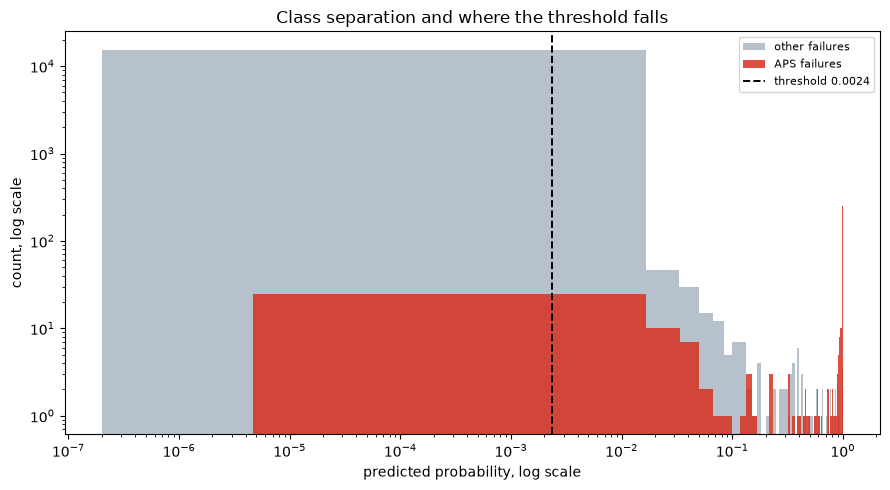

In [14]:
# Figure: where the errors sit
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(probability[other_mask], bins=60, alpha=0.6, log=True,
        label="other failures", color="#8899aa")
ax.hist(probability[y == 1], bins=60, alpha=0.85, log=True,
        label="APS failures", color="#d7301f")
ax.axvline(threshold, color="black", ls="--", lw=1.4,
           label=f"threshold {threshold:.4f}")

ax.set_xscale("log")
ax.set_xlabel("predicted probability, log scale")
ax.set_ylabel("count, log scale")
ax.set_title("Class separation and where the threshold falls")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_error_analysis.png", dpi=150)
plt.show()

## 5. Which variables the model relies on

Permutation importance is used rather than a model's internal importance. It
shuffles one column and measures the drop in performance, so it measures what
the model actually uses to predict, not how often a column appears in its
structure. It also works identically on all five model families, which the
internal measures do not.

The scoring function is the area under the precision-recall curve, the same
threshold-free measure used to select throughout the project.

One limitation must be stated. The dataset attributes are anonymised for
industrial confidentiality. The analysis can name which variable weighs, never
what it measures. The only exception is `depth_g1`, built in this project, whose
meaning is known.

In [15]:
from sklearn.inspection import permutation_importance

start = time.time()
importance = permutation_importance(model, X_test, y, scoring="average_precision",
                                    n_repeats=5, random_state=42, n_jobs=-1)
print(f"computed in {time.time() - start:.0f} s\n")

weights = pd.Series(importance.importances_mean, index=X_test.columns)
top = weights.sort_values(ascending=False).head(15)
print("fifteen most influential variables\n")
print(top.round(5).to_string())

computed in 18 s

fifteen most influential variables

aa_000    0.05740
ck_000    0.04042
ay_008    0.01451
ay_005    0.00947
ag_001    0.00908
ag_002    0.00902
ci_000    0.00868
bs_000    0.00724
bk_000    0.00476
ay_006    0.00471
ai_000    0.00349
ee_005    0.00337
bx_000    0.00308
bj_000    0.00299
bt_000    0.00289


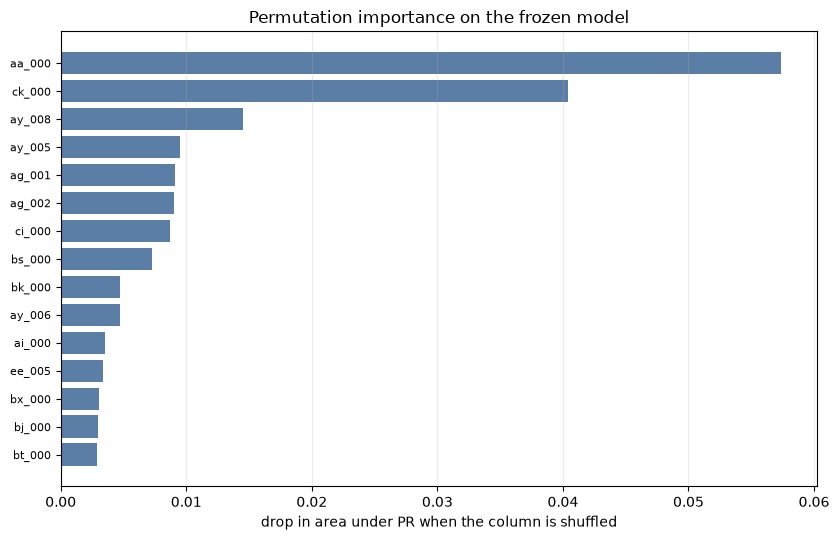

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(range(len(top)), top.values[::-1], color="#5b7ea6")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index[::-1], fontsize=8)
ax.set_xlabel("drop in area under PR when the column is shuffled")
ax.set_title("Permutation importance on the frozen model")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_permutation_importance.png", dpi=150)
plt.show()

weights.sort_values(ascending=False).to_csv(
    ROOT / "reports" / "variable_importance.csv")

In [17]:
# Do the constructed variables appear, and where?
built = ["depth_g1"] + [c for c in X_test.columns if c.startswith("missing_sb")]
rank = weights.rank(ascending=False).astype(int)

print(f"rank of the constructed variables, out of {len(weights)}\n")
for name in built:
    print(f"  {name:<16} rank {rank[name]:>4}   importance {weights[name]:.6f}")

print(f"\nrank of aa_000, the only complete column : {rank['aa_000']}")

print("\nThis is the third and last reading of decision D-09. The ablation")
print("measured no cost improvement from these variables; this measures whether")
print("the model uses them at all. A high rank with no cost gain means the")
print("model substitutes them for information it already had elsewhere.")

with open(ROOT / "reports" / "test_result.json", "w", encoding="utf-8") as handle:
    json.dump(result, handle, indent=2, ensure_ascii=False)

print("\nThe official test set will not be consulted again.")

rank of the constructed variables, out of 180

  depth_g1         rank  102   importance 0.000078
  missing_sb1      rank  160   importance -0.000212
  missing_sb2      rank   94   importance 0.000114
  missing_sb3      rank  146   importance -0.000055
  missing_sb4      rank  116   importance 0.000010
  missing_sb5      rank  101   importance 0.000082
  missing_sb6      rank   93   importance 0.000123
  missing_sb7      rank   87   importance 0.000160
  missing_sb8      rank  118   importance 0.000007
  missing_sb9      rank  113   importance 0.000025

rank of aa_000, the only complete column : 1

This is the third and last reading of decision D-09. The ablation
measured no cost improvement from these variables; this measures whether
the model uses them at all. A high rank with no cost gain means the
model substitutes them for information it already had elsewhere.

The official test set will not be consulted again.


## What comes out of this notebook

To be completed after execution, in five points.

The cost obtained, against the constant-rule reference and against the 2016
competition figures.

The detection rate, against the 90 % minimum set by the project brief.

The progression across the three measurements, and what it says about
generalisation.

The gap between the applied threshold and the post-hoc optimum, as a measure of
how well the operating point transports.

The verdict on the three hypotheses about missed failures, and which improvement
path it points to.